In [146]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au
from scipy.ndimage import gaussian_filter
import importlib
importlib.reload(au)

<module 'scripts.analysis_utils' from '/home/rns/work/Transmissivity/scripts/analysis_utils.py'>

In [147]:
data = np.concatenate((np.loadtxt('all_harmonics_output.txt'), 
                      np.loadtxt('2025_11_22_injections.txt'),
                      np.loadtxt('2025_11_28_injections.txt')))
print(f'Number of pointings: {len(np.unique(data[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data[data[:, -1] > 0.])/len(data)):.2f}%')
print(f'Number of injections: {len(data)}')

RA_idx = 0
Dec_idx = 1
f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
sigma_idx = 8

TPA_idx = data[:, 3].astype('int')
FWHM_array = np.load('../profiles/TPA_fwhm.npy')
FWHM = FWHM_array[TPA_idx]
jitter = np.random.uniform(0.85, 1.15, size=len(FWHM)) #to deal with discrete FWHM
data[:, FWHM_idx] = FWHM * jitter
#do the same for Dec
# Jitter by a fraction of the typical spacing between unique values
# unique_Dec = np.unique(data[:, Dec_idx])
# min_spacing = np.min(np.diff(unique_Dec))
# jitter = np.random.uniform(-20 * min_spacing, 20 * min_spacing, size=len(data[:, Dec_idx]))
# data[:, Dec_idx] += jitter

Number of pointings: 15129
Number of days: 8
Total fraction of recovered injections: 30.53%
Number of injections: 271967


In [148]:
f_bins = np.logspace(-3, 2.7, 250)
f_dev = 10
DM_bins = np.linspace(0, 700, 250)
DM_dev = 5
S_bins = np.logspace(-2, 1, 250)
S_dev = 10
FWHM_bins = np.logspace(-2.5, np.log10(0.15), 250)
FWHM_dev = 5
RA_bins = np.linspace(0, 360, 250)
RA_dev = 10
Dec_bins = np.linspace(min(data[:, Dec_idx]), max(data[:, Dec_idx]), 500)
Dec_dev = 40

In [149]:
f_inj_p_smooth, f_ret_p, f_ret_p_smooth = au.get_sensitivity(
    data, 
    *(f_idx, f_bins, f_dev)
)

DM_inj_p_smooth, DM_ret_p, DM_ret_p_smooth = au.get_sensitivity(
    data,
    *(DM_idx, DM_bins, DM_dev)
)


S_inj_p_smooth, S_ret_p, S_ret_p_smooth = au.get_sensitivity(
    data,
    *(S_idx, S_bins, S_dev)
)


FWHM_inj_p_smooth, FWHM_ret_p, FWHM_ret_p_smooth = au.get_sensitivity(
    data,
    *(FWHM_idx, FWHM_bins, FWHM_dev)
)


RA_inj_p_smooth, RA_ret_p, RA_ret_p_smooth = au.get_sensitivity(
    data,
    *(RA_idx, RA_bins, RA_dev)
)



Dec_inj_p_smooth, Dec_ret_p, Dec_ret_p_smooth = au.get_sensitivity(
    data,
    *(Dec_idx, Dec_bins, Dec_dev)
)


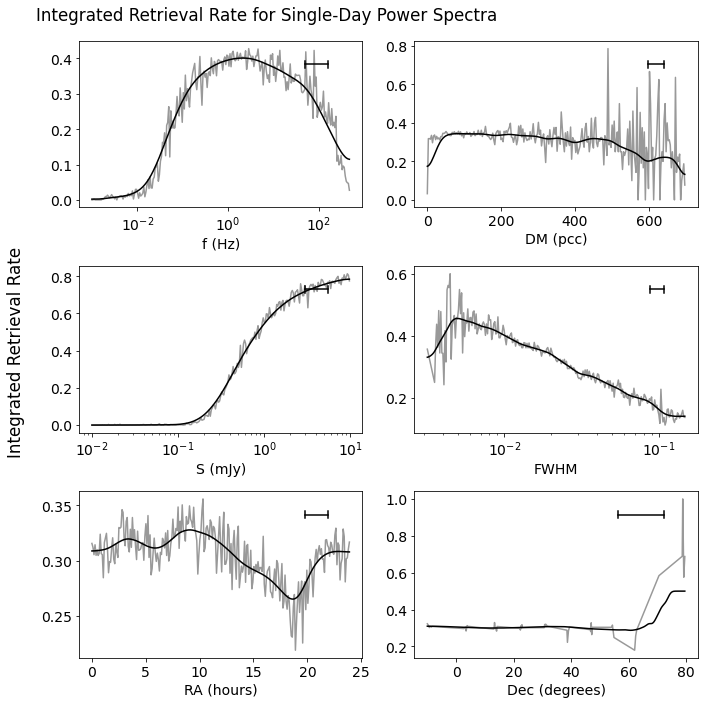

In [151]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
ax = ax.flatten()
ax[0].plot(f_bins[:-1], gaussian_filter(f_ret_p_smooth, 3), color='black', label='First')
ax[0].plot(f_bins[:-1], f_ret_p, alpha=0.4, color='black')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
au.add_crosshair(ax[0], f_bins, np.sqrt(f_dev**2 + 3**2))

ax[1].plot(DM_bins[:-1], gaussian_filter(DM_ret_p_smooth, 5), color='black', label='First')
ax[1].plot(DM_bins[:-1], DM_ret_p, alpha=0.4, color='black')
ax[1].set_xlabel('DM (pcc)')
au.add_crosshair(ax[1], DM_bins, np.sqrt(DM_dev**2 + 5**2))

ax[2].plot(S_bins[:-1], gaussian_filter(S_ret_p_smooth, 3), color='black', label='First')
ax[2].plot(S_bins[:-1], S_ret_p, alpha=0.4, color='black')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
au.add_crosshair(ax[2], S_bins, np.sqrt(S_dev**2 + 3**2))

ax[3].plot(FWHM_bins[:-1], gaussian_filter(FWHM_ret_p_smooth, 3), color='black', label='First')
ax[3].plot(FWHM_bins[:-1], FWHM_ret_p, alpha=0.4, color='black')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
au.add_crosshair(ax[3], FWHM_bins, np.sqrt(FWHM_dev**2 + 3**2))

ax[4].plot(RA_bins[:-1] / 15, gaussian_filter(RA_ret_p_smooth, 3), color='black', label='First')
ax[4].plot(RA_bins[:-1] / 15, RA_ret_p, alpha=0.4, color='black')
ax[4].set_xlabel('RA (hours)')
au.add_crosshair(ax[4], RA_bins, np.sqrt(RA_dev**2 + 3**2))

ax[5].plot(Dec_bins[:-1], gaussian_filter(Dec_ret_p_smooth, 5), color='black', label='First')
ax[5].plot(Dec_bins[:-1], Dec_ret_p, alpha=0.4, color='black')
ax[5].set_xlabel('Dec (degrees)')
au.add_crosshair(ax[5], Dec_bins, np.sqrt(Dec_dev**2 + 5**2))

fig.suptitle('Integrated Retrieval Rate for Single-Day Power Spectra', horizontalalignment='right', x = 0.7)
fig.supylabel('Integrated Retrieval Rate')
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
#            bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()